# Übung 3

**Gruppenname:**

*TKKR*

Christian Rene Thelen, Sasha Knarren, Isabelle K., Helena Rickmann

## In dieser Übung ...

... werden wir unsere erste "Besichtigung" unseres ersten Machine Learning Projektes abschließen und die Begriffe Trainingsset und Testset einführen (Aufgabe 3.1). Danach werden wir uns noch einmal kurz auf konzeptioneller Ebene Gedanken um die Fähigkeiten des Perzeptrons machen (Aufgabe 3.2). In Aufgabe 3.3 werden Sie Out-of-Sample Fehler mithilfe eines Testsets abschätzen, und in Übung 3.4 sich noch einmal kurz mit dem Schwertliliendatensatz aus der letzten Übung beschäftigen.


## 3.1 Trainingsset und Testset
Stellen Sie sich vor, Sie arbeiten bei einem innovativen Medizingeräte-Hersteller für Röntgengeräte. Ihre Vorgesetzte stellt Ihnen die Aufgabe, ein Machine Learning Modell zu entwickeln, das anhand von Röntgenbildern der Lunge entscheiden soll, ob ein Patient Lungenkrebs hat oder nicht. Sie erhalten 4000 Röntgenbilder (features) samt Diagnose (labels: Krebs ja/nein).

Lassen Sie uns vereinfachend annehmen, dass Sie aus den Röntgenbildern features (Eigenschaften) extrahieren, und dass Sie ein Perzeptron darauf trainieren, zwischen Fällen mit Krebs und denen ohne Krebs zu unterscheiden.

Bearbeiten Sie folgende Aufgaben:

(1) Sie wählen eine zufällige Hypothese aus dem Hypothesenset des Perzeptrons aus und bestimmen den In-Sample Fehler $E_\text{in}$ auf dem Datensatz (alle 4000 Daten). Ihr Perzeptron wird dann in den Geräten des Herstellers eingesetzt. 

* Können Sie eine Aussage darüber treffen, wie groß der Vorhersagefehler (out-of-sample Fehler $E_\text{out}$) Ihres Perzeptrons für die neuen Patienten sein wird? Begründen Sie Ihre Antwort in wenigen Sätzen. (Tipp: Welche Hoeffding-Ungleichung aus der Vorlesung kann Ihnen hier helfen?) 

Die Wahrscheinlichkeit, dass $E_\text{out}$ von $E_\text{in}$ um mehr als den Wert $\epsilon$ abweicht, beträgt $2M\exp(-2\epsilon^2 N)$.

Oder anders gesagt: Mit einer Wahrscheinlichkeit von mindestens $1-\delta$ wird $E_\text{out}(g)$ im Bereich 
$$
E_\text{in}(g) \pm \sqrt{\frac{1}{2\cdot N} \ln\left(\frac{2M}{\delta}\right)}
$$ liegen.

Zur Veranschaulichung betrachten wir mal eine gewünschte Sicherheit von $95\%$ (also eine Fehlerwahrscheinlichketi von $\delta = 0.05$).
Mit $N = 4000$ und $M = 1$ können wir nun sagen, dass mit $95\%$ Wahrscheinlichkeit der Out-of-Sample-Fehler $E_\text{out}$ im Bereich von
$$
\begin{aligned}
&E_\text{in}(g) \pm \sqrt{\frac{1}{8000} \ln\left(\frac{2}{0.05}\right)} \\
\approx\ & E_\text{in}(g) \pm  0.02147347
\end{aligned}
$$
liegt.

In [5]:
import numpy as np
def epsilon(delta, N, M):
    """
    delta: Fehlerwahrscheinlichkeit
    N:     Anzahl der unabhängigen, identisch verteilten Datenpunkte
    M:     Anzahl getesteter Hypothesen

    Rückgabe:
    Epsilon: Obere Schranke für |E_in – E_out| mit Wahrscheinlichkeit 1 - delta
    """
    return np.sqrt((1/(2*N)) * np.log((2*M)/delta))

epsilon(0.05, 4000, 1)

np.float64(0.02147347041733688)

(2) Nehmen wir an, dass Sie mit der Klassifikationsgenauigket des in Teilaufgabe (1) ausgewählten Perzeptron unzufrieden sind. Sie probieren weitere Hypothesen (Geraden) für Ihr Perzeptron aus. 

* Können Sie nun eine genauere Aussage darüber treffen, wie groß Ihr Vorhersagefehler für die zukünftigen Patienten sein wird? Begründen Sie in 1-2 Sätzen Ihre Antwort und nutzen Sie den Tipp aus der obigen Aufgabe.

Nein, da durch das Ausprobieren weiterer Hypothesen (und die Wahl der Hypothese, mit dem kleinsten $E_\text{in}$), die einfache Hoeffding-Ungleichung nicht mehr gilt, da die Hypothese nicht mehr unabhängig von den Trainingsdaten gewählt sind.

Wir können jedoch die Hoeffding-Ungleichung für mehrere Hypothesen (Union Bound) verwenden 
$$
\mathbb{P} [ |E_{\text{in}}(g) -  E_{\text{out}}(g)| > \epsilon] 
\leq 2M \exp\left(-2\epsilon^2 N\right)
$$
und stellen fest, dass durch das Testen weiterer Hypothesen $h_1,\cdots, h_M \in\mathcal{H}$ die Abweichung $\epsilon$ von $E_\text{in}$ größer wird.

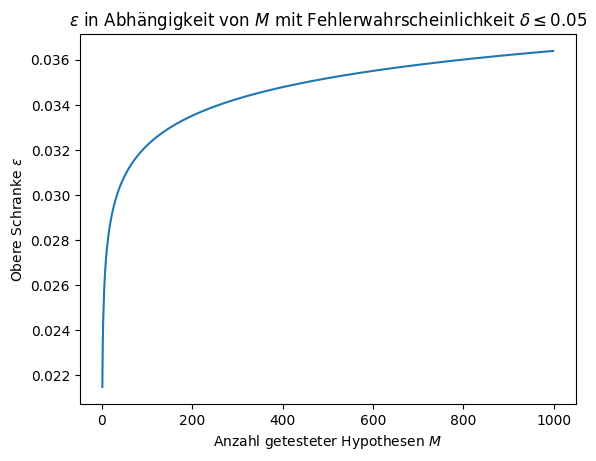

In [31]:
import matplotlib.pyplot as plt
plt.plot(np.arange(1, 1000, 1), epsilon(0.05, 4000, np.arange(1, 1000, 1)))
plt.title("$\\epsilon$ in Abhängigkeit von $M$ mit Fehlerwahrscheinlichkeit $\\delta \\leq 0.05$")
plt.xlabel("Anzahl getesteter Hypothesen $M$")
plt.ylabel("Obere Schranke $\\epsilon$")
plt.show()

(3) In einem echten Machine Learning Projekt würden Sie die Daten Ihrer Vorgesetzten entgegennehmen und in zwei Datensätze aufspalten: einem Trainingsset und einem Testset. Die prozentuale Aufteilung variiert je nach Projekt, aber typisch wäre 75% für das Trainingsset und 25% der Daten für das Testset. **Sie schließen die Daten im Testset weg und trainieren Ihr Perzeptron ausschließlich auf dem Trainingsset.** Nachdem das **Training auf dem Trainingsset** abgeschlossen ist, erhalten Sie Ihre finale Hypothese $g$, die Sie nun auf das Testset anwenden und dabei einen Klassifikationsfehler erhalten.

* Schlagen Sie die verschiedenen Hoeffding-Ungleichungen in der zweiten Vorlesung nach. Welche der Gleichungen gilt für das Trainingsset, welche für das Testset? 

Da das Testset nicht zum Training oder zur Wahl der Hypothese verwendet wird, gilt auf dem **Testset** die **einfache Hoeffding-Ungleichung**
$$
\mathbb{P} [ |E_{\text{in}}(g) -  E_{\text{out}}(g)| > \epsilon] \leq 2\exp\left(-2\epsilon^2 N_\text{test}\right)
$$
da die Hypothese $g$ festgelegt ist, bevor wir die Testdaten anschauen.

Auf dem **Trainingsset** hingegen gilt diese Gleichung nicht, da die Hypothese auf Basis der Trainingsdaten ausgewählt wurde, also $g\in\mathcal{H}$ abhängig von diesen Daten ist. Hier muss die Mächtigkeit des Hypothesenraums $M=|\mathcal{H}|$ berücksichtig werden:
$$
\mathbb{P} [ |E_{\text{in}}(g) -  E_{\text{out}}(g)| > \epsilon ] \leq 2 M \exp\left(-2\epsilon^2 N_\text{train}\right) 
$$

* Welchen Vorteil hat es, wenn Sie ein Testset verwenden, wenn Sie Ihrer Vorgesetzten eine möglichst präzise Vorhersage des Out-of-Sample Fehlers $E_\text{out}$ geben wollen? Begründen Sie Ihre Antwort in wenigen Sätzen.

Die Vorhersage des Out-of-Sample Fehlers einer finalen Hypothese $g$ kann auf dem Testset unabhängig von der Hypothesenauswahl und damit unabhängig von der Anzahl der getesteten Hypothesen $M$ getroffen werden. Damit kann die Vorhersage mit einer sehr hohen Wahrscheinlichkeit getroffen werden und wird nicht durch Overfitting verzerrt.

* Welchen Nachteil hat Ihrer Meinung nach die Aufteilung der Daten in Trainingsset und Testset? Begründen Sie Ihre Antwort in wenigen Sätzen.

Der Trainingsdatensatz wird kleiner wodurch weniger Daten für das Training zur Verfügung stehen. Dies kann zu einer schlechteren Modellanpassung und einem höheren In-Sample-Fehler führen.

(4) Nehmen wir einmal an, dass Ihr Perzeptron auf den Röntgenbild-Daten zu viele Fehler macht, d.h. Ihre finale Hypothese $g$, die Sie über das Trainingsset erhalten haben, erzeugt einen großen Klassifikationsfehler auf dem Testset. Sie trainieren nun eine Anzahl $Q$ weiterer Machine Learning Methoden auf Ihrem Trainingsset, zum Beispiel k-Nearest Neighbors oder Support Vector Machines. Auch für diese Methoden erhalten Sie finale Hypothesen $g_1,\ldots,g_Q$, deren Klassifikationsfehler Sie auf Ihrem Testset berechnen. Sie wählen dann aus $g_1,\ldots,g_Q$ die Hypothese $g^*$, die den kleinsten Klassifikationsfehler auf dem Testset erzielt.

* Welche der Hoeffding-Ungleichungen aus der Vorlesung gilt nun für das Testset? Verbessert oder verschlechtert sich Ihre Fähigkeit, mithilfe eines Klassifikationsfehlers auf dem Testset den Out-of-Sample Fehler $E_\text{out}$ für $g^*$ vorherzusagen?

In diesem Fall gilt die **Hoeffding-Ungleichung für $M$ Hypothesen** auch auf dem Testset, da dieses nun zur Modellselektion mit $M=Q$ Modellen verwendet wird.

(5) Es ist nicht ungewöhnlich, mehrere Machine Learning Methoden für ein Machine Learning Projekt auszuprobieren. Angenommen Sie planen, mehrere Machine Learning Methoden auf Ihr Trainingsset anzusetzen, um damit mehrere finale Hypothesen $g_i$ zu erhalten, aus denen Sie dann mithilfe des Testsets die beste finale Hypothese $g^*$ auswählen: 
* Haben Sie eine Idee, wie Sie die Daten, die Sie in Teilaufgabe (3) aufgespalten haben, anders aufspalten könnten, um möglichst genau den Out-of-Sample Fehler $E_\text{out}$ für die Hypothese $g^*$ vorherzusagen? Begründen Sie in wenigen Sätzen Ihre Idee.

- k-fold Cross-Validation:
  - Aufteilung in $k$ Folds
  - $k-1$ Folds zum Training
  - $1$ Fold zur Validierung
  - Wiederhole $k$-mal mit jeweils einem anderen Fold als Validierungsfold. 

- 3-Set Aufteilung:
  - Trainingsset, zum bestimmen der Hypothesen $g_i$
  - Validierungsset, zum Vergleichen und Auswählen der besten Hypothese $g^*$
  - Testset (hold-out), welches nur auf $g^*$ angewandt wird um eine unverzerrte Schätzung von $E_\text{out}$ zu erhalten.

**Schlussbemerkung:** Wenn Sie viele Hypothesen auf demselben Datensatz testen, dann sprechen Machine Learning-Experten umgangssprachlich gerne von einer "Erschöpfung", einem "Verbrauch" oder auch einer "Beschmutzung" des Datensatzes. Sie wissen natürlich, dass das Umgangssprache ist, die Sie nicht in Prüfungen oder in anderen offiziellen Situationen nutzen.

## 3.2 Das Perzeptron und ein US-amerikanischer Sportartikelhersteller

Ein bekannter US-amerikanischer Sportartikelhersteller hat vor einigen Jahren festgestellt, dass er zwei Kundensegmente hat:

1. männliche Teenager
2. Ältere Frauen

Dieser Fall ist echt und ich habe ihn mir nicht ausgedacht. Was das für die Marketingstrategie des Herstellers bedeutet, lassen wir einmal beiseite.

Hier kommt der Teil, den ich mir für Sie ausgedacht habe:

Sie erhalten Features von Personen, nämlich (1.) Alter und (2.) Geschlecht. Das Feature "Alter" entspricht nicht dem Alter in Jahren, sondern unterscheidet nur zwischen den beiden Gruppen "Jung" und "Alt". Sie sollen mithilfe eines Perzeptrons (also eines Neurons) vorhersagen, ob die Person zum potenziellen Kunden des Herstellers zählt (Label +1) oder nicht (Label -1).

**Ihre Aufgaben**

(1) Nehmen Sie sich ein Blatt Papier und zeichnen Sie darauf ein Koordinatensystem: Die y-Achse sei die Achse, auf der das Alter aufgetragen ist. Die x-Achse sei die Achse, auf der das Geschlecht von Mann nach Frau aufgetragen ist. (Wir nehmen vereinfachend ein Kontinuum an Geschlechtern an, was dem Stand der aktuellen Geschlechterforschung auch eher entspricht.)

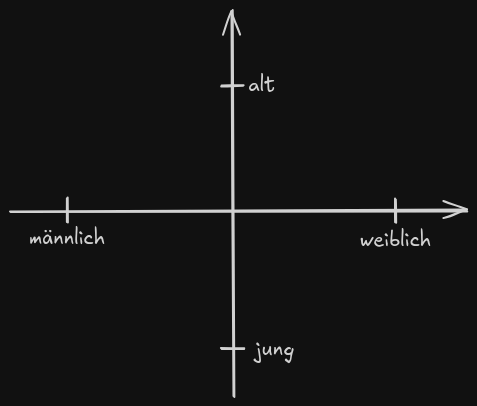

(2) Markieren Sie nun mit einer Farbe die Bereiche im Koordinatensystem, die zu den beiden obigen Kundensegmenten zählen. Markieren Sie dann mit einer anderen Farbe die Bereiche im Koordinatensystem, die **nicht** zu den beiden Kundensegmenten zählen.

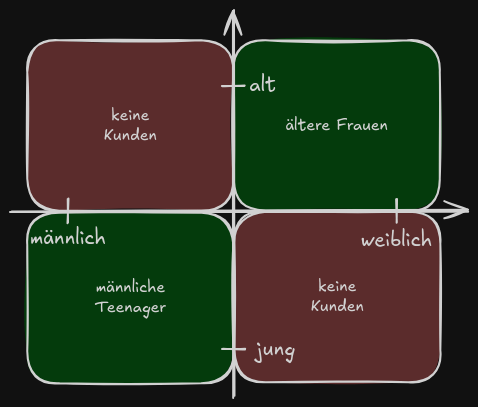

(3) Betrachten Sie Ihr Koordinatensystem: Können Sie mithilfe eines Perzeptrons (also einer Gerade) die Kunden von den Nicht-Kunden trennen? Beschreiben Sie mit 1-3 Sätzen Ihre Beobachtung.

Nein, in dieser Darstellung kann keine Gerade zur Trennung von Kunden und Nicht-Kunden verwendet werden.

(4) Wenn Sie die Frage aus Teilaufgabe (3) verneint haben: Könnten Sie mit mehr als einem Perzeptron die Kunden von den Nicht-Kunden trennen? Falls ja, wie würden Sie dies bewerkstelligen? Beschreiben Sie Ihren Ansatz in 1-3 Sätzen.

Es kann ein Perzeptron zur Unterscheidung zwischen männlich und weiblich genutzt werden. Bei den weiblichen Kunden kann ein Perzeptron, was nun zwischen alt und jung differenziert Kundinnen und Nicht-Kundinnen unterscheiden, während bei den männlichen Kunden ein anderes Perzeptron zwischen jung und alt differenzieren und damit Kunden und Nicht-Kunden unterscheiden kann.

**Schlussbemerkung:** Die Beobachtungen, die Sie gemacht haben, wurden in den 60er Jahren publiziert. Sie führten zum ersten großen Winter der KI-Forschung (KI: Künstliche Intelligenz), insbesondere für Forscherinnern und Forscher, die sich für künstliche Neuronen interessierten und damit der konnektionistischen Denkschule zuzuordnen waren: Für rund 15 Jahre brach die Finanzierung für konnektionistische Forschung, also Forschung an neuronalen Netzen ein, da man Schwierigkeiten hatte, die Idee, die Sie voraussichtlich bei Aufgabenschritt (4) formulierten, umzusetzen.

## 3.3 Trainieren und Testen
Sie haben in Aufgabe 3.1 bereits das Konzept des Trainingssets und des Testsets kennengelernt. Wir werden dieses Konzept auf unser Lernproblem von letzter Woche anwenden. 

Ich bitte Sie:

* Kopieren Sie Ihren Code für PLA und für das Perzeptron aus Ihrem alten Jupyter Notebook in dieses Jupyter Notebook.
* **Bevor Sie fortfahren,** hier noch ein Hinweis: Sollten Sie einmal aus Versehen eine Endlosschleife bauen und/oder Ihr Algorithmus terminiert nicht, dann wird das Schließen des Browserfensters den Rechenprozess (den Kernel) nicht stoppen. Er wird auf dem Server weiterlaufen. Stattdessen sollten Sie in diesem Fall den Kernel dieses *Jupyter Notebooks* stoppen durch das Menü `Kernel -> Interrupt` oder durch die Tastatur mit: `ESC` (Wechsel in den Command-Mode) und dann zweimal die Taste `i` drücken. Wenn Sie sich für weitere Informationen zu *Jupyter Notebook* interessieren, schauen Sie auch gerne im Tutorial im ILIAS Kurs (Übungsmodul) unter "Vorbereitungen, Aufgabe 1.1." nach.
* Vergessen Sie nicht, Ihr *Jupyter Notebook* ab und an zu speichern (mit der Tastenkombination `Strg` + `s`).

Unser Ziel ist es, den Vorhersagefehler, den Ihr trainiertes Perzeptron auf Daten macht, zu charakterisieren und zu quantifizieren.

**Ihre Aufgaben:**

(1) Betrachten Sie den unten angegebenen Code, der einen synthetischen Datensatz erzeugt. Adaptieren Sie diesen Code, sodass er Ihnen garantiert einen zufälligen Datensatz zurückliefert, der Punkte beider Labels enthält. (Als Hack könnten Sie `generate_decision_line` so oft aufrufen, bis Sie einen Datensatz erhalten, der Punkte beider Labels enthält (also mindestens einen Punkt mit einem Label und mindestens einen Punkt mit anderem Label.))

In [81]:
# Der folgende Code erzeugt Ihnen den synthetischen Datensatz,
# mit dem Sie schon in der letzten Woche gearbeitet haben.
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

def generate_points(N):
    return np.random.rand(N, 2)

def generate_decision_line():
    g = generate_points(2)
    m = (g[1, 1]-g[1, 0])/(g[0, 1]-g[0, 0])
    b = g[1, 0]-m*g[0, 0]
    def getY(x):
        return m*x+b
    func = getY
    return func

def getClassedPoints(N):
    tf = generate_decision_line()  # target function
    X = generate_points(N)  # data set
    labels = np.array([1 if tf(X[i, 0]) > X[i, 1] else -1 for i in range(X.shape[0]) ])  # labels
    return X, labels, tf

(2) Erzeugen Sie einen synthetischen Datensatz von 32 Datenpunkten.

In [125]:
# obtain points p, targets t, and decision line g
X, y, target_function = getClassedPoints(32)

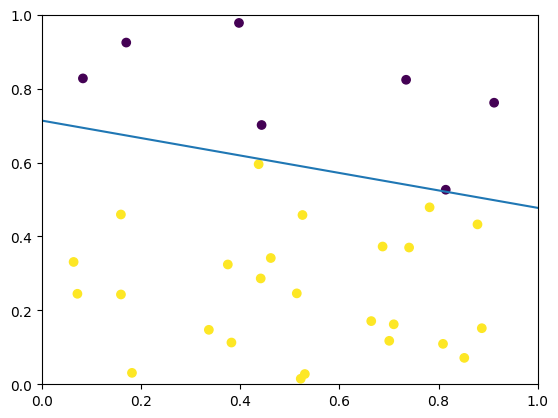

In [126]:
# plot points
plt.axis((0, 1, 0, 1))
plt.scatter(X[:,0], X[:,1], c=y)

# plot decision line
l = np.linspace(0, 1, 2)
plt.plot(l, target_function(l))

(3) Teilen Sie diesen Datensatz auf in ein Trainingsset (75%) und ein Testset (25%).

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

(4) Trainieren Sie ein Perzeptron mithilfe Ihres Perzeptron-Lern-Algorithmus von letzter Woche auf Ihrem Trainingsset und generieren Sie Ihre finale Hypothese $g$ (also die finale Gerade).

In [128]:
def h(x, w):
    return np.sign(np.dot(w.T, x))

def pla(X, y, w=None):
    if w is None:
        w = np.zeros(X.shape[1] + 1)
    for index, x in enumerate(np.column_stack((np.ones(X.shape[0]), X))):
        if h(x, w) != y[index]:
            return pla(X, y, w + y[index]*x)
            break
    return w

def get_hypothesis_g(w):
    return lambda x: ((w[1]/w[2])*(-x)) - (w[0]/w[2])

def predict(X: np.ndarray, g: callable):
    arr_bool = g_final(X[:,0]) > X[:,1]
    return np.where(arr_bool, 1, -1)

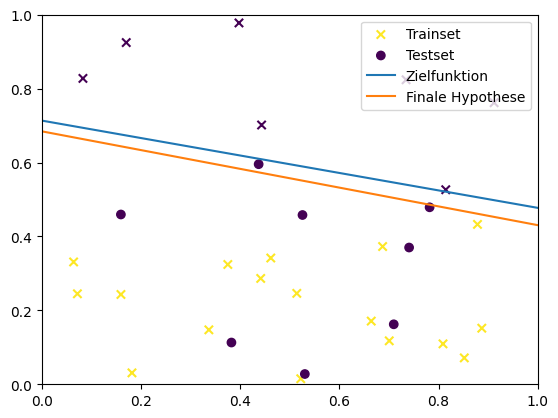

In [129]:
w = pla(X_train, y_train)
g_final = get_hypothesis_g(w)

# plot points
plt.axis((0, 1, 0, 1))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, marker='x', label="Trainset")
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, marker='o', label="Testset")

# plot decision line
l = np.linspace(0, 1, 2)
plt.plot(l, target_function(l), label="Zielfunktion")
plt.plot(l, g_final(l), label="Finale Hypothese")
plt.legend(loc="upper right")
plt.show()

(5) Sei $N_1$ die Anzahl der Datenpunkte in Ihrem Trainingsset. Definieren Sie den Klassifikationsfehler wie folgt: 
$E_\text{in}(g) = \frac{1}{N_1}\sum_{i=1}^{N_1} [[g(\mathbf{x_i})\neq y_i)]]$, wobei $[[\cdot]]=1$ falls der Ausdruck $\cdot$ zutrifft; ansonsten ist $[[\cdot]]=0$.

* Berechnen Sie den Klassifikationsfehler auf dem Trainingsset. Welchen Wert erhalten Sie? Begründen Sie kurz, warum Sie genau diesen Klassifikationsfehler erhalten müssen. (Tipp: Wie arbeitet PLA?)

In [130]:
y_train_predicted = predict(X_train, g_final)
y_train_predicted

array([ 1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
        1, -1, -1,  1, -1,  1, -1])

In [131]:
def calc_error(y, y_pred):
    assert y.shape == y_pred.shape
    N = y.shape[0]
    return 1/N * sum([1 for a in range(y.shape[0]) if y[a] != y_pred[a]])

In [132]:
E_in = calc_error(y_train, y_train_predicted)
E_in

0.0

(6) Sei $N_2$ die Anzahl der Datenpunkte in Ihrem Testset. Definieren Sie den Klassifikationsfehler wie folgt: 
$E_\text{test}(g) = \frac{1}{N_2}\sum_{j=1}^{N_2} [[g(\mathbf{x_j})\neq y_j]]$, wobei $[[\cdot]]=1$ falls der Ausdruck $\cdot$ zutrifft; ansonsten ist $[[\cdot]]=0$.

 * Berechnen Sie den Klassifikationsfehler $E_\text{test}$ auf dem Testset. Dieser Fehler ist Ihr Anhaltspunkt, welchen Fehler $E_\text{out}$ Sie erwarten können.

In [133]:
E_test = calc_error(y_test, predict(X_test, g_final))
E_test

0.125

(7) Erzeugen Sie nun ein Ensemble von 100 Datensätzen (je 32 Datenpunkte), unterteilen Sie diese in Training- und Testsets (wie in den vorigen Schritten) und berechnen Sie den Mittelwert von $E_\text{test}$ über dieses Ensemble.

In [136]:
import sys
sys.setrecursionlimit(60000)

In [137]:
E_tests = []
for i in range(100):
    X, y, _ = getClassedPoints(32)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    w = pla(X_train, y_train)
    g_final = get_hypothesis_g(w)
    E_tests.append(calc_error(y_test, predict(X_test, g_final)))

print(f"E_test Mean: {np.mean(E_tests):.6f}")

E_test Mean: 0.102500


(8) Wiederholen Sie Schritt 7, aber verkleinern Sie $N_1$ (und vergrößern Sie damit $N_2$) in Schritten von 4 (also: $N_1=24, 20, 16, \ldots,4$). Ermitteln Sie jeweils die Mittelwerte $E_\text{test}$. Zeichnen Sie in einer Abbildung den Mittelwert $E_\text{test}$ (y-Achse) gegen $N_1$ (x-Achse). Was beobachten Sie?

In [150]:
E_tests_means = []
for n_1 in range(24, 3, -4):

    for i in range(100):
        X, y, _ = getClassedPoints(32)
        X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=n_1, random_state=42)
        w = pla(X_train, y_train)
        g_final = get_hypothesis_g(w)
        E_tests.append(calc_error(y_test, predict(X_test, g_final)))

    E_tests_means.append(np.mean(E_tests))
    print(f"{n_1}: E_test Mean: {np.mean(E_tests):.6f}")

24: E_test Mean: 0.179268
20: E_test Mean: 0.178602
16: E_test Mean: 0.178682
12: E_test Mean: 0.178719
8: E_test Mean: 0.179451
4: E_test Mean: 0.183572


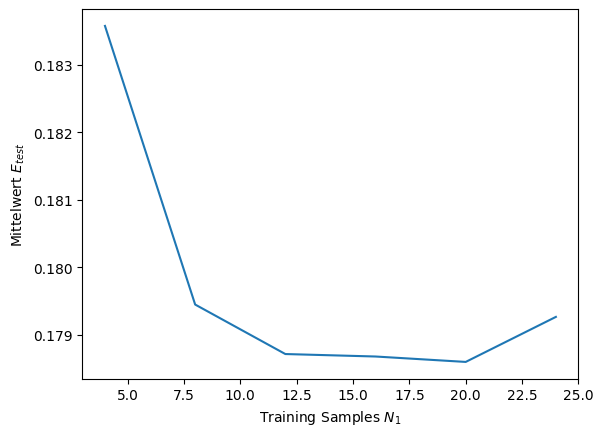

In [153]:
plt.plot(range(24, 3, -4), E_tests_means)
plt.ylabel("Mittelwert $E_{test}$")
plt.xlabel("Training Samples $N_1$")
plt.show()

(9) Erklären Sie Ihre Beobachtungen aus Schritt 8 (wenige Sätze) mithilfe der Hoeffding Ungleichung aus der Vorlesung. Vergegenwärtigen Sie sich dazu auch Ihre Überlegungen zu $E_\text{in}$ in Schritt 5. 

## 3.4 Trainieren und Testen - Teil 2 (Optional)

Oft werden Trainingsset und Testset so definiert, dass die ersten 75% der Daten dem Trainingsset und die restlichen 25% der Daten dem Testset zugeschrieben werden. Schauen Sie in die alten Übungen nach und betrachten Sie dort den Schwertliliendatensatz.

**Ihre Aufgaben**

(1) Betrachten Sie die Labels des Schwertliliendatensatzes. Fällt Ihnen eine Besonderheit auf, wie die Daten in diesem Datensatz organisiert sind?

(2) Was würde passieren, wenn Sie einfach die letzten 25% des Datensatzes als Testset nutzen würden? Welche Auswirkungen vermuten Sie?

(3) Wie würden Sie anstelle der in Punkt (2) vorgeschlagenen Aufteilung in Training- und Testset eine Aufteilung vornehmen?

Diese kleine Übung zeigt Ihnen einen typischen Fallstrick, der Ihnen bei echten Daten (also nicht synthetischen) häufig begegnet.